# 📋 File 04 — Đánh giá mô hình (Evaluation)
**Brain Tumor Classification MRI Dataset**

File này đánh giá toàn diện model tốt nhất từ file 03 trên **Test set**:
- Accuracy, Precision, Recall, F1-Score theo từng class
- Confusion Matrix (số lượng + tỷ lệ %)
- ROC Curve và AUC Score
- Grad-CAM: xem model đang nhìn vào vùng nào của ảnh MRI
- Phân tích ảnh dự đoán sai
- Tổng kết toàn bộ dự án

⚠️ **Lưu ý:** Chạy file này SAU KHI đã chạy xong file 03!

## 📦 Phần A — Import thư viện

In [12]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from pathlib import Path

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

plt.style.use('seaborn-v0_8-whitegrid')
print(f'✅ TensorFlow: {tf.__version__}')
print('✅ Import thư viện thành công!')

✅ TensorFlow: 2.21.0
✅ Import thư viện thành công!


## ⚙️ Phần B — Load cấu hình và model tốt nhất từ file 03

In [13]:
PROJECT_ROOT = Path.cwd()
DATA_DIR  = PROJECT_ROOT / 'data'
TEST_DIR  = DATA_DIR / 'Testing'
CSV_DIR   = PROJECT_ROOT

IMG_SIZE    = (240, 240)
BATCH_SIZE  = 32
RANDOM_SEED = 42
NUM_CLASSES = 4

CLASSES = ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']
CLASS_LABELS = {
    'glioma_tumor':     'Glioma',
    'meningioma_tumor': 'Meningioma',
    'no_tumor':         'Khong co u',
    'pituitary_tumor':  'Pituitary'
}
LABEL_NAMES = [CLASS_LABELS[c] for c in CLASSES]

assert TEST_DIR.exists(), f'Missing testing folder: {TEST_DIR}'


def build_dataframe(base_dir, classes):
    records = []
    for cls in classes:
        cls_path = base_dir / cls
        for ext in ('*.jpg', '*.jpeg', '*.png'):
            for img_path in cls_path.glob(ext):
                records.append({'filepath': str(img_path.resolve()), 'label': cls})
    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError(f'No images found under {base_dir}')
    return df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)

test_csv = CSV_DIR / 'df_test.csv'
if test_csv.exists():
    df_test = pd.read_csv(test_csv)
    paths_ok = df_test['filepath'].map(lambda p: Path(p).exists()).all()
    labels_ok = set(df_test['label'].unique()).issubset(set(CLASSES))
    if not paths_ok or not labels_ok:
        print('df_test.csv is stale/invalid. Rebuilding from ./data/Testing ...')
        df_test = build_dataframe(TEST_DIR, CLASSES)
        df_test.to_csv(test_csv, index=False)
else:
    print('df_test.csv missing. Rebuilding from ./data/Testing ...')
    df_test = build_dataframe(TEST_DIR, CLASSES)
    df_test.to_csv(test_csv, index=False)

print(f'Test set: {len(df_test)} images')
print(f'Distribution: {df_test["label"].value_counts().reindex(CLASSES).to_dict()}')

if Path('best_tl_model.h5').exists():
    model = keras.models.load_model('best_tl_model.h5', compile=False)
    MODEL_NAME = 'EfficientNetB0 Transfer Learning'
    print('\nLoaded: best_tl_model.h5')
elif Path('best_cnn_model.h5').exists():
    model = keras.models.load_model('best_cnn_model.h5', compile=False)
    MODEL_NAME = 'CNN Baseline'
    print('\nLoaded: best_cnn_model.h5')
else:
    raise FileNotFoundError('No model found. Expected best_tl_model.h5 or best_cnn_model.h5')

print(f'Model: {MODEL_NAME}')

Test set: 1994 images
Distribution: {'glioma_tumor': 500, 'meningioma_tumor': 515, 'no_tumor': 505, 'pituitary_tumor': 474}

Loaded: best_tl_model.h5
Model: EfficientNetB0 Transfer Learning


In [14]:
# ============================================================
# Create test generator
# shuffle=False keeps predictions aligned with true labels.
# ============================================================
test_datagen = ImageDataGenerator()

test_generator = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='filepath',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=CLASSES,
    shuffle=False
)

CLASS_INDICES  = test_generator.class_indices
INDEX_TO_CLASS = {v: k for k, v in CLASS_INDICES.items()}
print(f'Class indices: {CLASS_INDICES}')
print(f'Test generator samples: {test_generator.samples}')

Found 1994 validated image filenames belonging to 4 classes.
Class indices: {'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}
Test generator samples: 1994


## 🔮 Phần C — Dự đoán toàn bộ Test Set

Đưa toàn bộ test set qua model để lấy:
- `y_pred_proba`: xác suất cho mỗi class (dùng cho ROC)
- `y_pred`: class có xác suất cao nhất (dùng cho Confusion Matrix, F1...)
- `y_true`: nhãn thật từ dataset

In [15]:
# ============================================================
# Predict toàn bộ test set
# ============================================================
print('🔮 Dang du doan tren Test set...')

# y_pred_proba shape: (n_samples, 4) — xác suất mỗi class
y_pred_proba = model.predict(test_generator, verbose=1)

# Lấy class có xác suất cao nhất
y_pred = np.argmax(y_pred_proba, axis=1)

# Nhãn thật từ generator
y_true = test_generator.classes

# Chuyển index → tên class để in báo cáo
y_pred_names = [INDEX_TO_CLASS[i] for i in y_pred]
y_true_names = [INDEX_TO_CLASS[i] for i in y_true]

# Accuracy cơ bản
test_accuracy = np.mean(y_pred == y_true)
n_correct = np.sum(y_pred == y_true)
n_wrong   = np.sum(y_pred != y_true)

print(f'\n✅ Hoan tat du doan!')
print(f'   Dung : {n_correct} / {len(y_true)}')
print(f'   Sai  : {n_wrong}  / {len(y_true)}')
print(f'   Test Accuracy: {test_accuracy*100:.2f}%')

🔮 Dang du doan tren Test set...
63/63 ━━━━━━━━━━━━━━━━━━━━ 41s 618ms/step

✅ Hoan tat du doan!
   Dung : 1591 / 1994
   Sai  : 403  / 1994
   Test Accuracy: 79.79%


## 📊 Phần D — Classification Report chi tiết

**Giải thích từng chỉ số:**
- **Precision**: Trong số model nói là *Glioma*, bao nhiêu % thực sự là Glioma? → Đo mức độ "tin tưởng" của model
- **Recall (Sensitivity)**: Trong tất cả ảnh Glioma thật, model tìm được bao nhiêu %? → Quan trọng trong y tế (không bỏ sót bệnh)
- **F1-Score**: Trung bình hài hoà Precision và Recall → Chỉ số cân bằng nhất
- **Support**: Số ảnh thật của class đó trong test set

In [16]:
# ============================================================
# Classification report
# ============================================================
report_dict = classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=LABEL_NAMES,
    output_dict=True,
    zero_division=0
)

print('=' * 65)
print(f'CLASSIFICATION REPORT - {MODEL_NAME}')
print('=' * 65)
print(classification_report(
    y_true, y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=LABEL_NAMES,
    zero_division=0
))

CLASSIFICATION REPORT - EfficientNetB0 Transfer Learning
              precision    recall  f1-score   support

      Glioma       0.67      0.83      0.74       500
  Meningioma       0.85      0.60      0.70       515
  Khong co u       0.79      0.96      0.87       505
   Pituitary       0.96      0.81      0.88       474

    accuracy                           0.80      1994
   macro avg       0.82      0.80      0.80      1994
weighted avg       0.82      0.80      0.80      1994



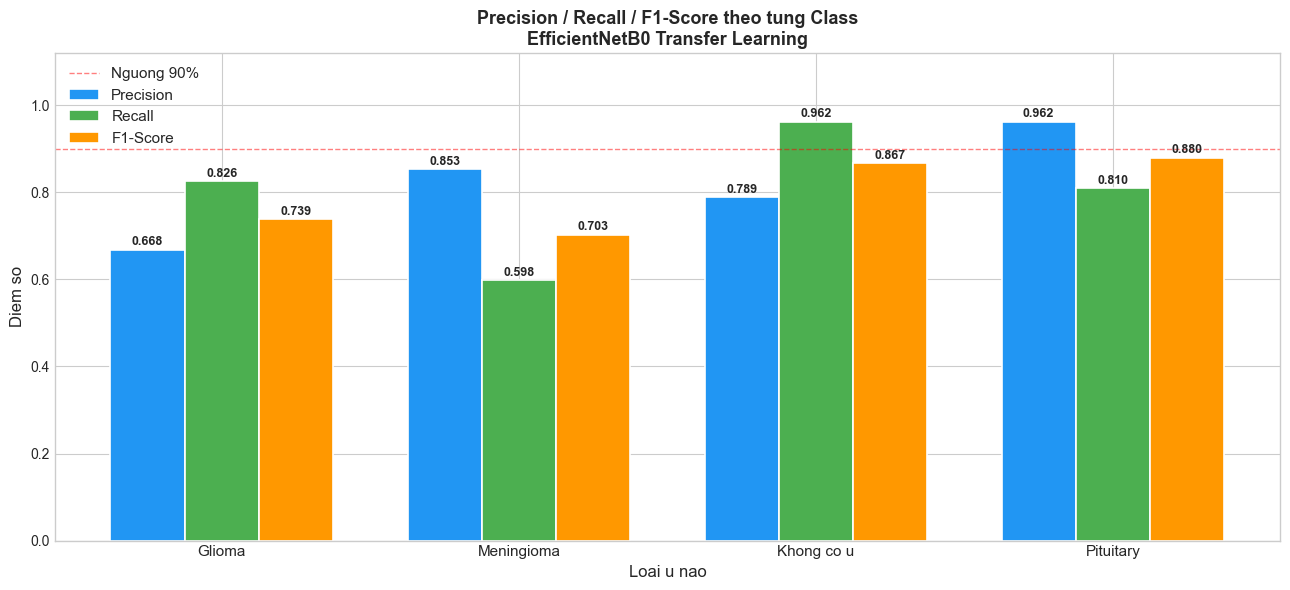

Saved: eval_metrics_by_class.png


In [17]:
# ============================================================
# Vẽ biểu đồ Precision / Recall / F1 theo từng class
# ============================================================
metrics = {
    'Precision': [report_dict[l]['precision'] for l in LABEL_NAMES],
    'Recall':    [report_dict[l]['recall']    for l in LABEL_NAMES],
    'F1-Score':  [report_dict[l]['f1-score']  for l in LABEL_NAMES],
}

x     = np.arange(len(LABEL_NAMES))
width = 0.25
colors_bar = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (metric_name, values) in enumerate(metrics.items()):
    bars = ax.bar(x + i*width, values, width,
                  label=metric_name, color=colors_bar[i],
                  edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.01,
                f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title(f'Precision / Recall / F1-Score theo tung Class\n{MODEL_NAME}',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Loai u nao', fontsize=12)
ax.set_ylabel('Diem so', fontsize=12)
ax.set_xticks(x + width)
ax.set_xticklabels(LABEL_NAMES, fontsize=11)
ax.set_ylim([0, 1.12])
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.5, linewidth=1, label='Nguong 90%')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eval_metrics_by_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eval_metrics_by_class.png')

## 🔲 Phần E — Confusion Matrix

**Đọc ma trận:**
- Hàng = nhãn **thật**
- Cột = nhãn **dự đoán**
- **Đường chéo** (từ trái trên → phải dưới) = dự đoán **đúng**
- **Ngoài đường chéo** = dự đoán **sai** và hay nhầm với class nào

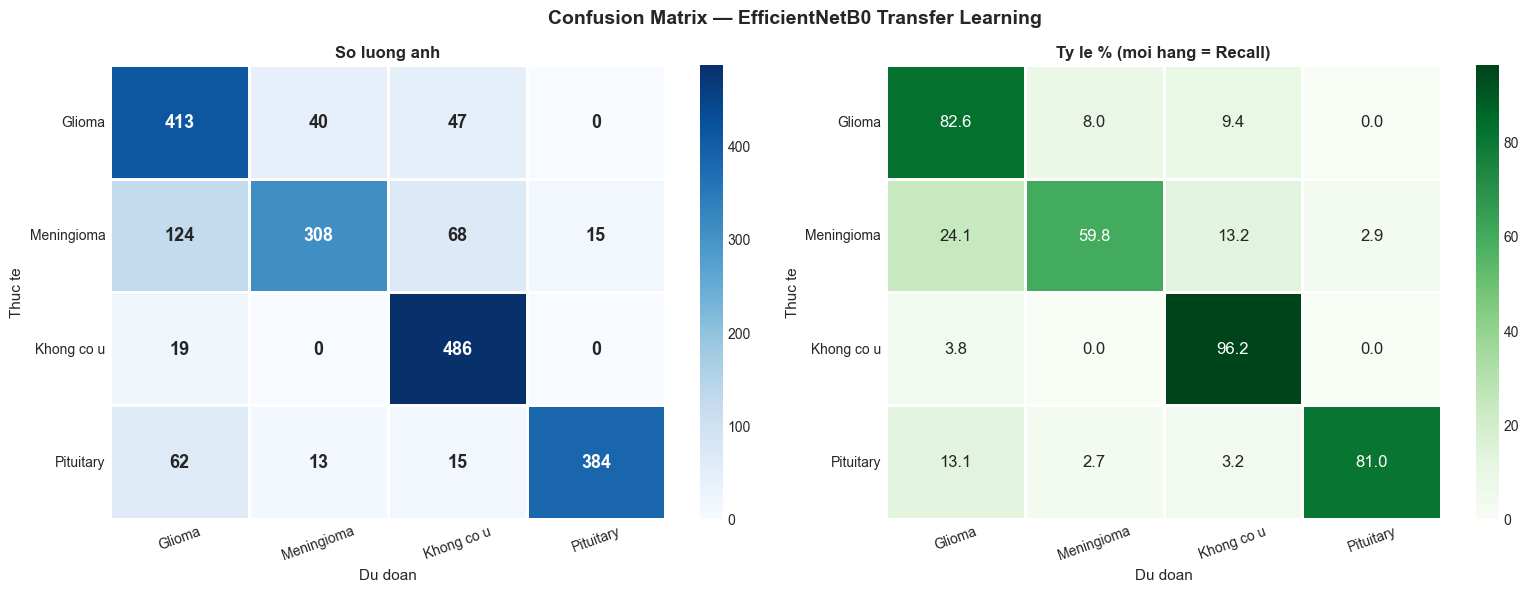


Phan tich nham lan chinh:
  Glioma          -> hay bi nham thanh "Khong co u" (47 lan)
  Meningioma      -> hay bi nham thanh "Glioma" (124 lan)
  Khong co u      -> hay bi nham thanh "Glioma" (19 lan)
  Pituitary       -> hay bi nham thanh "Glioma" (62 lan)


In [18]:
# ============================================================
# Vẽ Confusion Matrix — 2 dạng: số lượng và tỷ lệ %
# ============================================================
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Confusion Matrix — {MODEL_NAME}',
             fontsize=14, fontweight='bold')

# --- Dạng 1: Số lượng tuyệt đối ---
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    linewidths=0.8, linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    ax=axes[0]
)
axes[0].set_title('So luong anh', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Du doan', fontsize=11)
axes[0].set_ylabel('Thuc te', fontsize=11)
axes[0].tick_params(axis='x', rotation=20)
axes[0].tick_params(axis='y', rotation=0)

# --- Dạng 2: Tỷ lệ % theo hàng (= Recall mỗi class) ---
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(
    cm_pct, annot=True, fmt='.1f', cmap='Greens',
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES,
    linewidths=0.8, linecolor='white',
    annot_kws={'size': 12},
    ax=axes[1]
)
axes[1].set_title('Ty le % (moi hang = Recall)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Du doan', fontsize=11)
axes[1].set_ylabel('Thuc te', fontsize=11)
axes[1].tick_params(axis='x', rotation=20)
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig('eval_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Phân tích: class nào hay bị nhầm với class nào?
print('\nPhan tich nham lan chinh:')
for i, true_label in enumerate(LABEL_NAMES):
    row = cm[i].copy()
    row[i] = 0
    if row.max() > 0:
        confused_with = LABEL_NAMES[row.argmax()]
        print(f'  {true_label:<15} -> hay bi nham thanh "{confused_with}" ({row.max()} lan)')

## 📈 Phần F — ROC Curve & AUC

**ROC Curve** đo khả năng phân biệt đúng/sai của model ở mọi ngưỡng.

**AUC (Area Under Curve):**
- AUC = 1.0 → hoàn hảo
- AUC = 0.5 → không khá hơn đoán ngẫu nhiên
- AUC > 0.95 → xuất sắc cho bài toán y tế

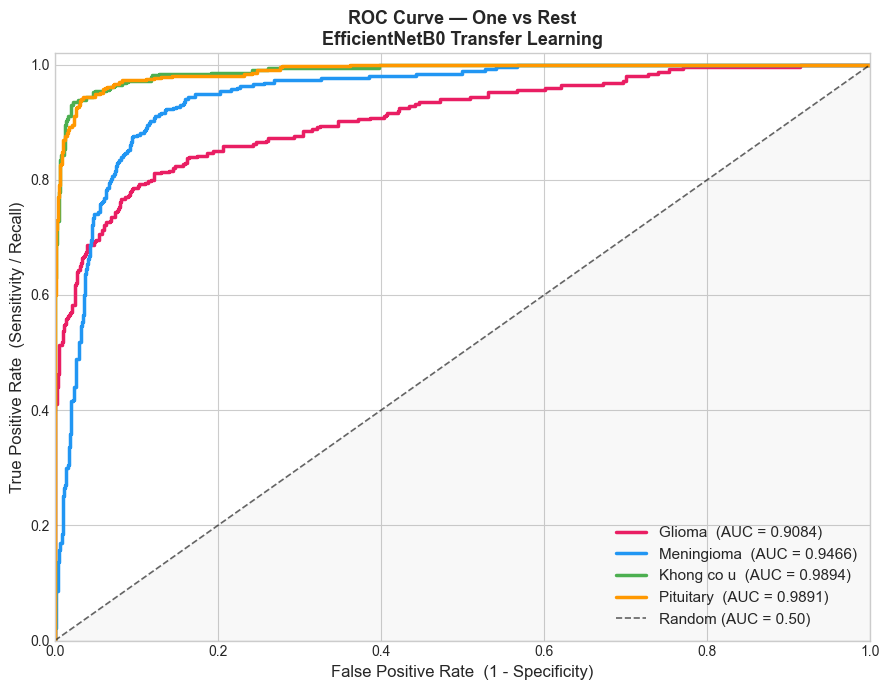

AUC Score tung class:
  Glioma          AUC = 0.9084  |||||||||||||||||||||||||||
  Meningioma      AUC = 0.9466  ||||||||||||||||||||||||||||
  Khong co u      AUC = 0.9894  |||||||||||||||||||||||||||||
  Pituitary       AUC = 0.9891  |||||||||||||||||||||||||||||

  Mean AUC = 0.9584


In [19]:
# ============================================================
# Vẽ ROC Curve theo phương pháp One-vs-Rest
# Mỗi class được coi là positive, còn lại là negative
# ============================================================

# Binarize nhãn thật: [0,1,2,3] → ma trận one-hot shape (n, 4)
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

fig, ax = plt.subplots(figsize=(9, 7))
colors_roc = ['#E91E63', '#2196F3', '#4CAF50', '#FF9800']
auc_scores = {}

for i, (label, color) in enumerate(zip(LABEL_NAMES, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    auc_score   = auc(fpr, tpr)
    auc_scores[label] = auc_score
    ax.plot(fpr, tpr, color=color, linewidth=2.5,
            label=f'{label}  (AUC = {auc_score:.4f})')

# Đường tham chiếu — random classifier
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.2, alpha=0.6,
        label='Random (AUC = 0.50)')

ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate  (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate  (Sensitivity / Recall)', fontsize=12)
ax.set_title(f'ROC Curve — One vs Rest\n{MODEL_NAME}',
             fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('eval_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print('AUC Score tung class:')
for label, score in auc_scores.items():
    bar = '|' * int(score * 30)
    print(f'  {label:<15} AUC = {score:.4f}  {bar}')
print(f'\n  Mean AUC = {np.mean(list(auc_scores.values())):.4f}')

## 🌡️ Phần G — Grad-CAM: Model đang nhìn vào đâu?

**Grad-CAM (Gradient-weighted Class Activation Mapping)** tạo heatmap
chỉ ra vùng nào của ảnh MRI mà model tập trung khi dự đoán.

- **Vùng đỏ/vàng** = model chú ý nhiều nhất
- **Vùng xanh/tím** = model ít chú ý

Rất quan trọng để kiểm tra xem model có đang nhìn vào đúng khối u không!

In [ ]:
# ============================================================
# Grad-CAM helpers - compatible with old .h5 + Keras 3/TensorFlow 2.21
# ============================================================
print('Grad-CAM helper version: forward-pass fix')

def get_gradcam_target_layer(model):
    """Return the last reachable 4D feature-map layer for Grad-CAM."""
    for layer in reversed(model.layers):
        if isinstance(layer, tf.keras.layers.Conv2D):
            return layer

    # Transfer-learning backbones such as EfficientNet are usually nested models.
    for layer in reversed(model.layers):
        try:
            output_shape = tuple(layer.output.shape)
        except Exception:
            continue
        if len(output_shape) == 4:
            return layer
    raise ValueError('No reachable 4D feature layer found for Grad-CAM.')


def _call_layer(layer, inputs, training=False):
    if isinstance(layer, tf.keras.layers.InputLayer):
        return inputs
    try:
        return layer(inputs, training=training)
    except TypeError:
        return layer(inputs)


def make_gradcam_heatmap(img_array, model, target_layer):
    with tf.GradientTape() as tape:
        x = tf.convert_to_tensor(img_array)
        feature_maps = None
        for layer in model.layers:
            x = _call_layer(layer, x, training=False)
            if layer is target_layer:
                feature_maps = x
        predictions = x
        if feature_maps is None:
            raise ValueError(f'Target layer {target_layer.name} was not reached during the forward pass.')
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, feature_maps)
    if grads is None:
        raise ValueError(
            f'Gradients are None for layer {target_layer.name}. '
            'Choose a convolution/feature-map layer that is connected to the model output.'
        )
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = feature_maps[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy(), int(pred_index)


def overlay_heatmap(img_bgr, heatmap, target_size, alpha=0.45):
    display_size = (target_size[1], target_size[0])
    img_rgb = cv2.cvtColor(cv2.resize(img_bgr, display_size), cv2.COLOR_BGR2RGB)
    heat = cv2.resize(heatmap, display_size)
    heat = np.uint8(255 * np.clip(heat, 0, 1))
    heat_color = cv2.applyColorMap(heat, cv2.COLORMAP_JET)
    heat_color = cv2.cvtColor(heat_color, cv2.COLOR_BGR2RGB)
    blended = cv2.addWeighted(img_rgb, 1 - alpha, heat_color, alpha, 0)
    return img_rgb, blended


target_layer = get_gradcam_target_layer(model)
print(f'? Grad-CAM target layer: {target_layer.name}, output={target_layer.output.shape}')


In [ ]:
# ============================================================
# V? Grad-CAM ? ?u ti?n 1 ?nh d? ?o?n ??NG m?i class
# ============================================================
fig, axes = plt.subplots(len(CLASSES), 3, figsize=(13, len(CLASSES) * 4))
if len(CLASSES) == 1:
    axes = np.expand_dims(axes, axis=0)
fig.suptitle('Grad-CAM ? Vung model tap trung khi du doan',
             fontsize=14, fontweight='bold')

col_titles = ['Anh goc', 'Heatmap', 'Goc + Heatmap']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=12, fontweight='bold', pad=10)

print(f'? Using Grad-CAM layer: {target_layer.name}')


def labels_to_indices(values):
    arr = np.atleast_1d(np.asarray(values))
    if np.issubdtype(arr.dtype, np.integer):
        return arr.astype(int)

    label_to_idx = {**CLASS_INDICES, **{label: i for i, label in enumerate(LABEL_NAMES)}}
    return np.array([label_to_idx.get(str(v), -1) for v in arr], dtype=int)


y_true_gc = labels_to_indices(y_true)
y_pred_gc = labels_to_indices(y_pred)

for row, cls in enumerate(CLASSES):
    cls_idx = CLASS_INDICES[cls]
    correct_idx = np.where((y_true_gc == cls_idx) & (y_pred_gc == cls_idx))[0]

    if len(correct_idx) > 0:
        sample_idx = correct_idx[0]
        sample_note = 'Dung'
    else:
        cls_indices = np.where(y_true_gc == cls_idx)[0]
        if len(cls_indices) == 0:
            for col in range(3):
                axes[row, col].text(0.5, 0.5, 'Khong co anh',
                                    ha='center', va='center', transform=axes[row, col].transAxes)
                axes[row, col].axis('off')
            continue
        sample_idx = cls_indices[np.argmax(y_pred_proba[cls_indices, cls_idx])]
        sample_note = 'Sai - mau gan nhat'
        print(f'Khong co anh dung cho {cls}; dung fallback sample #{sample_idx}.')

    img_path = df_test.iloc[sample_idx]['filepath']
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print(f'Khong doc duoc anh: {img_path}')
        for col in range(3):
            axes[row, col].axis('off')
        continue

    img_rgb_for_model = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb_for_model, (model_input_w, model_input_h))
    img_arr = img_resized.astype('float32')
    img_arr = np.expand_dims(img_arr, axis=0)

    try:
        heatmap, pred_idx = make_gradcam_heatmap(img_arr, model, target_layer)
        orig_rgb, blended = overlay_heatmap(img_bgr, heatmap, IMG_SIZE)
        confidence = y_pred_proba[sample_idx][pred_idx] * 100

        axes[row, 0].imshow(orig_rgb)
        axes[row, 0].set_ylabel(CLASS_LABELS[cls], fontsize=12,
                                 fontweight='bold', rotation=0,
                                 labelpad=70, va='center')
        axes[row, 0].axis('off')

        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].axis('off')

        pred_cls = INDEX_TO_CLASS[pred_idx]
        title_color = 'green' if pred_idx == cls_idx else 'red'
        axes[row, 2].imshow(blended)
        axes[row, 2].set_title(f'{sample_note}
Du doan: {CLASS_LABELS[pred_cls]} ({confidence:.1f}%)',
                                fontsize=10, color=title_color)
        axes[row, 2].axis('off')

    except Exception as e:
        print(f'Loi Grad-CAM cho {cls}: {e}')
        for col in range(3):
            axes[row, col].axis('off')

plt.tight_layout()
gradcam_output = OUTPUT_DIR / 'eval_gradcam.png' if 'OUTPUT_DIR' in globals() else 'eval_gradcam.png'
plt.savefig(gradcam_output, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {gradcam_output}')


## ❌ Phần H — Phân tích ảnh dự đoán SAI

Xem trực tiếp những ảnh model đoán sai để hiểu điểm yếu.
Từ đây có thể cải thiện model bằng cách thêm data augmentation
hoặc điều chỉnh kiến trúc.

So anh du doan sai: 403 / 1994 (20.2%)


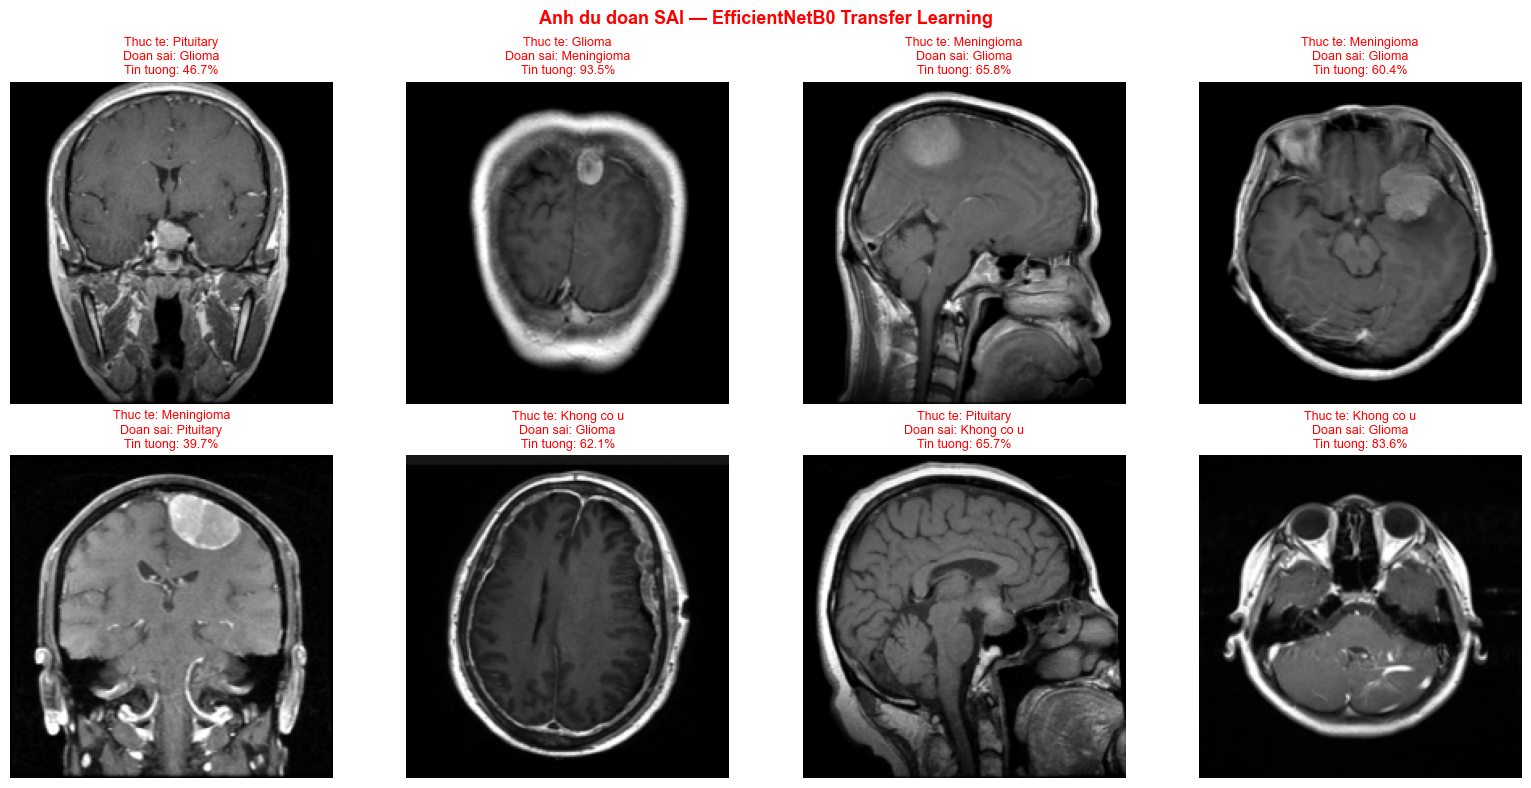

Saved: eval_wrong_predictions.png


In [ ]:
# ============================================================
# Hiển thị 8 ảnh dự đoán sai đầu tiên
# ============================================================
wrong_indices = np.where(y_pred != y_true)[0]
print(f'So anh du doan sai: {len(wrong_indices)} / {len(y_true)} '
      f'({len(wrong_indices)/len(y_true)*100:.1f}%)')

N_SHOW = min(8, len(wrong_indices))

if N_SHOW == 0:
    print('Model du doan dung het! Khong co anh sai.')
else:
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'Anh du doan SAI — {MODEL_NAME}',
                 fontsize=13, fontweight='bold', color='red')
    axes = axes.flatten()

    for i, idx in enumerate(wrong_indices[:N_SHOW]):
        img_path   = df_test.iloc[idx]['filepath']
        img        = cv2.imread(img_path)
        img        = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img        = cv2.resize(img, (200, 200))

        true_label = CLASS_LABELS[INDEX_TO_CLASS[y_true[idx]]]
        pred_label = CLASS_LABELS[INDEX_TO_CLASS[y_pred[idx]]]
        conf       = y_pred_proba[idx][y_pred[idx]] * 100

        axes[i].imshow(img)
        axes[i].set_title(
            f'Thuc te: {true_label}\nDoan sai: {pred_label}\nTin tuong: {conf:.1f}%',
            fontsize=9, color='red'
        )
        axes[i].axis('off')

    for j in range(N_SHOW, 8):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig('eval_wrong_predictions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: eval_wrong_predictions.png')

## ✅ Phần I — Tổng kết toàn bộ dự án

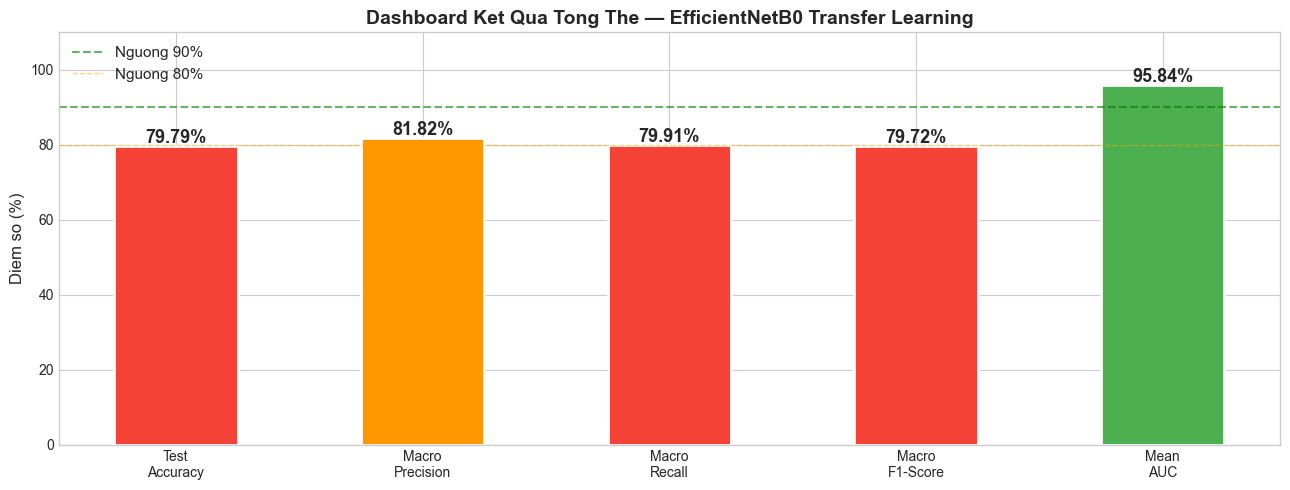

In [ ]:
# ============================================================
# Vẽ dashboard tổng kết dạng ảnh
# ============================================================
macro_p   = report_dict['macro avg']['precision']
macro_r   = report_dict['macro avg']['recall']
macro_f1  = report_dict['macro avg']['f1-score']
mean_auc  = np.mean(list(auc_scores.values()))

summary_metrics = {
    'Test\nAccuracy': test_accuracy,
    'Macro\nPrecision': macro_p,
    'Macro\nRecall': macro_r,
    'Macro\nF1-Score': macro_f1,
    'Mean\nAUC': mean_auc
}

fig, ax = plt.subplots(figsize=(13, 5))
bar_colors = ['#4CAF50' if v >= 0.9 else '#FF9800' if v >= 0.8 else '#F44336'
              for v in summary_metrics.values()]

bars = ax.bar(summary_metrics.keys(),
              [v * 100 for v in summary_metrics.values()],
              color=bar_colors, edgecolor='white', linewidth=2, width=0.5)

for bar, (k, v) in zip(bars, summary_metrics.items()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{v*100:.2f}%', ha='center', fontsize=13, fontweight='bold')

ax.axhline(y=90, color='green', linestyle='--', alpha=0.6, linewidth=1.5, label='Nguong 90%')
ax.axhline(y=80, color='orange', linestyle='--', alpha=0.5, linewidth=1, label='Nguong 80%')
ax.set_ylim([0, 110])
ax.set_ylabel('Diem so (%)', fontsize=12)
ax.set_title(f'Dashboard Ket Qua Tong The — {MODEL_NAME}',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('eval_summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# In báo cáo tổng kết cuối cùng
# ============================================================
print('=' * 62)
print('  BAO CAO TONG KET DU AN')
print('  Brain Tumor Classification MRI')
print('=' * 62)
print(f'  Model         : {MODEL_NAME}')
print(f'  Test set      : {len(y_true)} anh')
print(f'  Du doan dung  : {n_correct} anh')
print(f'  Du doan sai   : {n_wrong} anh')
print()
print('  Chi so tong the:')
print(f'    Test Accuracy    : {test_accuracy*100:.2f}%')
print(f'    Macro Precision  : {macro_p*100:.2f}%')
print(f'    Macro Recall     : {macro_r*100:.2f}%')
print(f'    Macro F1-Score   : {macro_f1*100:.2f}%')
print(f'    Mean AUC         : {mean_auc:.4f}')
print()
print('  F1-Score tung class:')
for label in LABEL_NAMES:
    f1  = report_dict[label]['f1-score']
    acc = report_dict[label]['recall']
    bar = '|' * int(f1 * 25)
    print(f'    {label:<15} F1={f1:.3f}  Recall={acc:.3f}  {bar}')
print()
print('  File da luu:')
files = [
    'eval_metrics_by_class.png  — Bieu do Precision/Recall/F1',
    'eval_confusion_matrix.png  — Ma tran nham lan',
    'eval_roc_curve.png         — Duong cong ROC va AUC',
    'eval_gradcam.png           — Grad-CAM heatmap',
    'eval_wrong_predictions.png — Anh du doan sai',
    'eval_summary_dashboard.png — Dashboard tong ket',
]
for f in files:
    print(f'    {f}')
print()
print('  HOAN TAT TOAN BO PIPELINE!')
print('  01_EDA → 02_Preprocessing → 03_Model → 04_Evaluation')
print('=' * 62)

  BAO CAO TONG KET DU AN
  Brain Tumor Classification MRI
  Model         : EfficientNetB0 Transfer Learning
  Test set      : 1994 anh
  Du doan dung  : 1591 anh
  Du doan sai   : 403 anh

  Chi so tong the:
    Test Accuracy    : 79.79%
    Macro Precision  : 81.82%
    Macro Recall     : 79.91%
    Macro F1-Score   : 79.72%
    Mean AUC         : 0.9584

  F1-Score tung class:
    Glioma          F1=0.739  Recall=0.826  ||||||||||||||||||
    Meningioma      F1=0.703  Recall=0.598  |||||||||||||||||
    Khong co u      F1=0.867  Recall=0.962  |||||||||||||||||||||
    Pituitary       F1=0.880  Recall=0.810  |||||||||||||||||||||

  File da luu:
    eval_metrics_by_class.png  — Bieu do Precision/Recall/F1
    eval_confusion_matrix.png  — Ma tran nham lan
    eval_roc_curve.png         — Duong cong ROC va AUC
    eval_gradcam.png           — Grad-CAM heatmap
    eval_wrong_predictions.png — Anh du doan sai
    eval_summary_dashboard.png — Dashboard tong ket

  HOAN TAT TOAN BO PIPELIN